# Baseline-модели для классификации тональности отзывов

На этом этапе обучаются и сравниваются несколько классических моделей машинного обучения для задачи классификации тональности пользовательских отзывов.

Используемые модели: DummyClassifier, Multinomial Naive Bayes, Logistic Regression.

Для представления текста используется TF-IDF.
Качество моделей оценивается по accuracy, precision, recall и macro-F1.

## Импорты, пути, загрузка данных

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)


PROCESSED_DATA_PATH = Path("../data/processed/reviews_prepared.csv")
REPORTS_DIR = Path("../reports")

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA_PATH)

df.head()

,text,sentiment
0,качество плохое пошив ужасный горловина напере...,negative
1,"товар отдали другому человеку, я не получила п...",negative
2,"ужасная синтетика! тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"кофточка голая синтетика, носить не возможно.",negative


## Train/test split

In [2]:
dataset_summary = pd.DataFrame({
    "Показатель": [
        "Количество строк",
        "Количество колонок",
        "Колонка с текстом",
        "Целевая переменная",
        "Количество классов"
    ],
    "Значение": [
        df.shape[0],
        df.shape[1],
        "text",
        "sentiment",
        df["sentiment"].nunique()
    ]
})

display(dataset_summary)
display(df["sentiment"].value_counts().rename_axis("sentiment").reset_index(name="count"))

,Показатель,Значение
0,Количество строк,86146
1,Количество колонок,2
2,Колонка с текстом,text
3,Целевая переменная,sentiment
4,Количество классов,3


,sentiment,count
0,positive,28956
1,negative,28817
2,neutral,28373


In [3]:
X = df["text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

split_summary = pd.DataFrame({
    "Subset": ["train", "test"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Share": [X_train.shape[0] / df.shape[0], X_test.shape[0] / df.shape[0]]
})

split_summary

,Subset,Rows,Share
0,train,68916,0.799991
1,test,17230,0.200009


## Baseline-модели

In [4]:
models = {
    "DummyClassifier": Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("classifier", DummyClassifier(strategy="most_frequent"))
    ]),
    
    "MultinomialNB": Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2)
        )),
        ("classifier", MultinomialNB())
    ]),
    
    "LogisticRegression": Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2)
        )),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
}

pd.DataFrame({
    "Model": list(models.keys()),
    "Text representation": ["TF-IDF", "TF-IDF", "TF-IDF"],
    "Comment": [
        "Baseline without real learning",
        "Fast probabilistic model for text classification",
        "Strong classical baseline for sparse text features"
    ]
})

,Model,Text representation,Comment
0,DummyClassifier,TF-IDF,Baseline without real learning
1,MultinomialNB,TF-IDF,Fast probabilistic model for text classification
2,LogisticRegression,TF-IDF,Strong classical baseline for sparse text feat...


## Обучение и сравнение моделей

In [5]:
results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    })
    
    trained_models[model_name] = model

results_df = (
    pd.DataFrame(results)
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)

results_df

,model,accuracy,precision_macro,recall_macro,f1_macro
0,LogisticRegression,0.748114,0.751678,0.747561,0.749160
1,MultinomialNB,0.725421,0.735236,0.725120,0.726756
2,DummyClassifier,0.336100,0.112033,0.333333,0.167702


In [6]:
best_model_name = results_df.loc[0, "model"]
best_model = trained_models[best_model_name]
best_predictions = best_model.predict(X_test)

best_model_name

'LogisticRegression'

In [7]:
report_dict = classification_report(
    y_test,
    best_predictions,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose().round(4)

report_df

,precision,recall,f1-score,support
negative,0.7438,0.7141,0.7286,5764.0000
neutral,0.6268,0.6733,0.6492,5675.0000
positive,0.8845,0.8553,0.8696,5791.0000
accuracy,0.7481,0.7481,0.7481,0.7481
macro avg,0.7517,0.7476,0.7492,17230.0000
weighted avg,0.7525,0.7481,0.7499,17230.0000


## Confusion matrix для лучшей модели

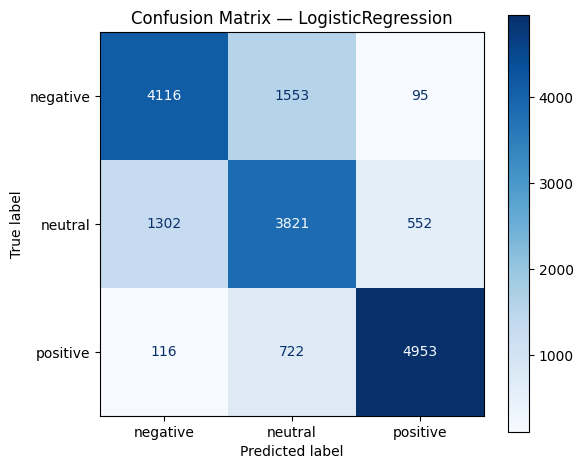

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    labels=["negative", "neutral", "positive"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix.png", dpi=200)
plt.show()

## Сохранение metrics.json и выводы

In [9]:
metrics = {
    "models": results_df.to_dict(orient="records"),
    "best_model": best_model_name,
    "best_model_classification_report": report_dict
}

metrics_path = REPORTS_DIR / "metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=4)

metrics_path

WindowsPath('../reports/metrics.json')

## Выводы

В ходе эксперимента были обучены и сравнены три baseline-модели: DummyClassifier, Multinomial Naive Bayes и Logistic Regression.

DummyClassifier используется как нижняя граница качества. MultinomialNB является быстрым классическим алгоритмом для текстовой классификации. Logistic Regression показывает более сильный baseline для разреженных TF-IDF-признаков.

Лучшей baseline-моделью стала Logistic Regression. Она показала accuracy около 0.748 и macro-F1 около 0.749 на тестовой выборке.

Лучшая модель выбирается по macro-F1, так как эта метрика учитывает качество классификации по всем классам и подходит для многоклассовой задачи.